# 💰 Análisis de Beneficios - Comparación de Modelos LLM

Este notebook compara el **rendimiento financiero** de 4 modelos LLM en trading:

- **Llama-3.3-70B**: Modelo más grande e inteligente
- **Llama-3.1-8B**: Modelo rápido (actual)
- **Llama-4-Scout-17B**: Última generación
- **Qwen3-32B**: Arquitectura alternativa

## 1️⃣ Importar Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos

In [12]:
try:
    df = pd.read_csv('model_comparison.csv')
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    
    print(f"✅ Datos cargados exitosamente")
    print(f"📊 Total de registros: {len(df)}")
    print(f"📅 Período: {df['Timestamp'].min()} a {df['Timestamp'].max()}")
    print(f"🔢 Número de ciclos: {df['Cycle'].nunique()}")
    print(f"🤖 Modelos: {', '.join(df['Model_Name'].unique())}")
    
except FileNotFoundError:
    print("❌ ERROR: Archivo 'model_comparison.csv' no encontrado")
    print("Por favor, ejecuta primero: python model_comparison.py")

✅ Datos cargados exitosamente
📊 Total de registros: 5028
📅 Período: 2025-10-13 14:03:26 a 2025-10-18 20:45:28
🔢 Número de ciclos: 651
🤖 Modelos: Llama-3.3-70B, Llama-3.1-8B, Llama-4-Scout-17B, Qwen3-32B


In [3]:
# Verificar señales con ERROR
error_signals = df[df['Model_Signal'] == 'ERROR']
if len(error_signals) > 0:
    print(f"⚠️  ADVERTENCIA: Se encontraron {len(error_signals)} señales con ERROR")
    print(f"   Esto significa que esos modelos fallaron al generar una respuesta.")
    print(f"   Las señales ERROR serán tratadas como HOLD (no hacer nada).\n")
    
    # Mostrar distribución de errores por modelo
    error_by_model = error_signals.groupby('Model_Name').size()
    print("Errores por modelo:")
    for model, count in error_by_model.items():
        total_signals = len(df[df['Model_Name'] == model])
        error_pct = (count / total_signals) * 100
        print(f"  • {model}: {count} errores ({error_pct:.1f}%)")
    print()
else:
    print("✅ No se encontraron señales con ERROR")

⚠️  ADVERTENCIA: Se encontraron 9 señales con ERROR
   Esto significa que esos modelos fallaron al generar una respuesta.
   Las señales ERROR serán tratadas como HOLD (no hacer nada).

Errores por modelo:
  • Llama-4-Scout-17B: 9 errores (0.7%)



## 3️⃣ Calcular Beneficios Acumulados

### Estrategia de Simulación:
- **Capital inicial**: $10,000 por modelo
- **BUY**: Compra 1 BTC (posición larga)
- **SELL**: Venta en corto de 1 BTC (posición corta)
- **HOLD**: Mantiene posición actual
- **Comisión**: 0.1% por operación

Calculamos el P&L (Profit & Loss) real basado en el cambio de precio entre señales.

In [4]:
# Parámetros de simulación
INITIAL_CAPITAL = 10000  # $10,000 USD inicial
COMMISSION_RATE = 0.001  # 0.1% por operación
POSITION_SIZE = 1        # 1 BTC por operación

def simulate_trading(model_df):
    """
    Simula trading basado en señales del modelo
    Retorna array con capital acumulado en cada momento
    """
    capital = INITIAL_CAPITAL
    position = None  # None, 'LONG', 'SHORT'
    entry_price = 0
    capital_history = [INITIAL_CAPITAL]
    
    for i in range(len(model_df)):
        signal = model_df.iloc[i]['Model_Signal']
        current_price = model_df.iloc[i]['Price']
        
        # Cerrar posición si existe
        if position is not None:
            if position == 'LONG':
                # Cerrar LONG: vender
                price_change = current_price - entry_price
                pnl = price_change * POSITION_SIZE
                commission = current_price * POSITION_SIZE * COMMISSION_RATE
                capital += pnl - commission
            
            elif position == 'SHORT':
                # Cerrar SHORT: comprar
                price_change = entry_price - current_price
                pnl = price_change * POSITION_SIZE
                commission = current_price * POSITION_SIZE * COMMISSION_RATE
                capital += pnl - commission
            
            position = None
        
        # Abrir nueva posición según señal
        if signal == 'BUY':
            position = 'LONG'
            entry_price = current_price
            commission = current_price * POSITION_SIZE * COMMISSION_RATE
            capital -= commission
        
        elif signal == 'SELL':
            position = 'SHORT'
            entry_price = current_price
            commission = current_price * POSITION_SIZE * COMMISSION_RATE
            capital -= commission
        
        # HOLD o ERROR: mantener posición actual (no hacer nada)
        
        capital_history.append(capital)
    
    return capital_history[1:]  # Remover capital inicial duplicado

print("✅ Función de simulación creada")

✅ Función de simulación creada


## 4️⃣ Simular Trading para Cada Modelo

In [5]:
# Preparar datos por modelo
models = df['Model_Name'].unique()
results = {}

print("🚀 Simulando trading para cada modelo...\n")

for model in models:
    model_df = df[df['Model_Name'] == model].sort_values('Timestamp').reset_index(drop=True)
    capital_history = simulate_trading(model_df)
    
    final_capital = capital_history[-1]
    profit = final_capital - INITIAL_CAPITAL
    roi = (profit / INITIAL_CAPITAL) * 100
    
    results[model] = {
        'capital_history': capital_history,
        'timestamps': model_df['Timestamp'].tolist(),
        'final_capital': final_capital,
        'profit': profit,
        'roi': roi
    }
    
    emoji = "📈" if profit > 0 else "📉"
    print(f"{emoji} {model}:")
    print(f"   Capital Final: ${final_capital:,.2f}")
    print(f"   Beneficio: ${profit:,.2f}")
    print(f"   ROI: {roi:.2f}%\n")

print("✅ Simulación completada")

🚀 Simulando trading para cada modelo...

📉 Llama-3.3-70B:
   Capital Final: $-133,286.36
   Beneficio: $-143,286.36
   ROI: -1432.86%

📉 Llama-3.1-8B:
   Capital Final: $-167,714.17
   Beneficio: $-177,714.17
   ROI: -1777.14%

📉 Llama-4-Scout-17B:
   Capital Final: $-130,457.00
   Beneficio: $-140,457.00
   ROI: -1404.57%

📉 Qwen3-32B:
   Capital Final: $9,661.57
   Beneficio: $-338.43
   ROI: -3.38%

✅ Simulación completada
📉 Llama-4-Scout-17B:
   Capital Final: $-130,457.00
   Beneficio: $-140,457.00
   ROI: -1404.57%

📉 Qwen3-32B:
   Capital Final: $9,661.57
   Beneficio: $-338.43
   ROI: -3.38%

✅ Simulación completada


## 5️⃣ 📊 GRÁFICO DE BENEFICIOS ACUMULADOS

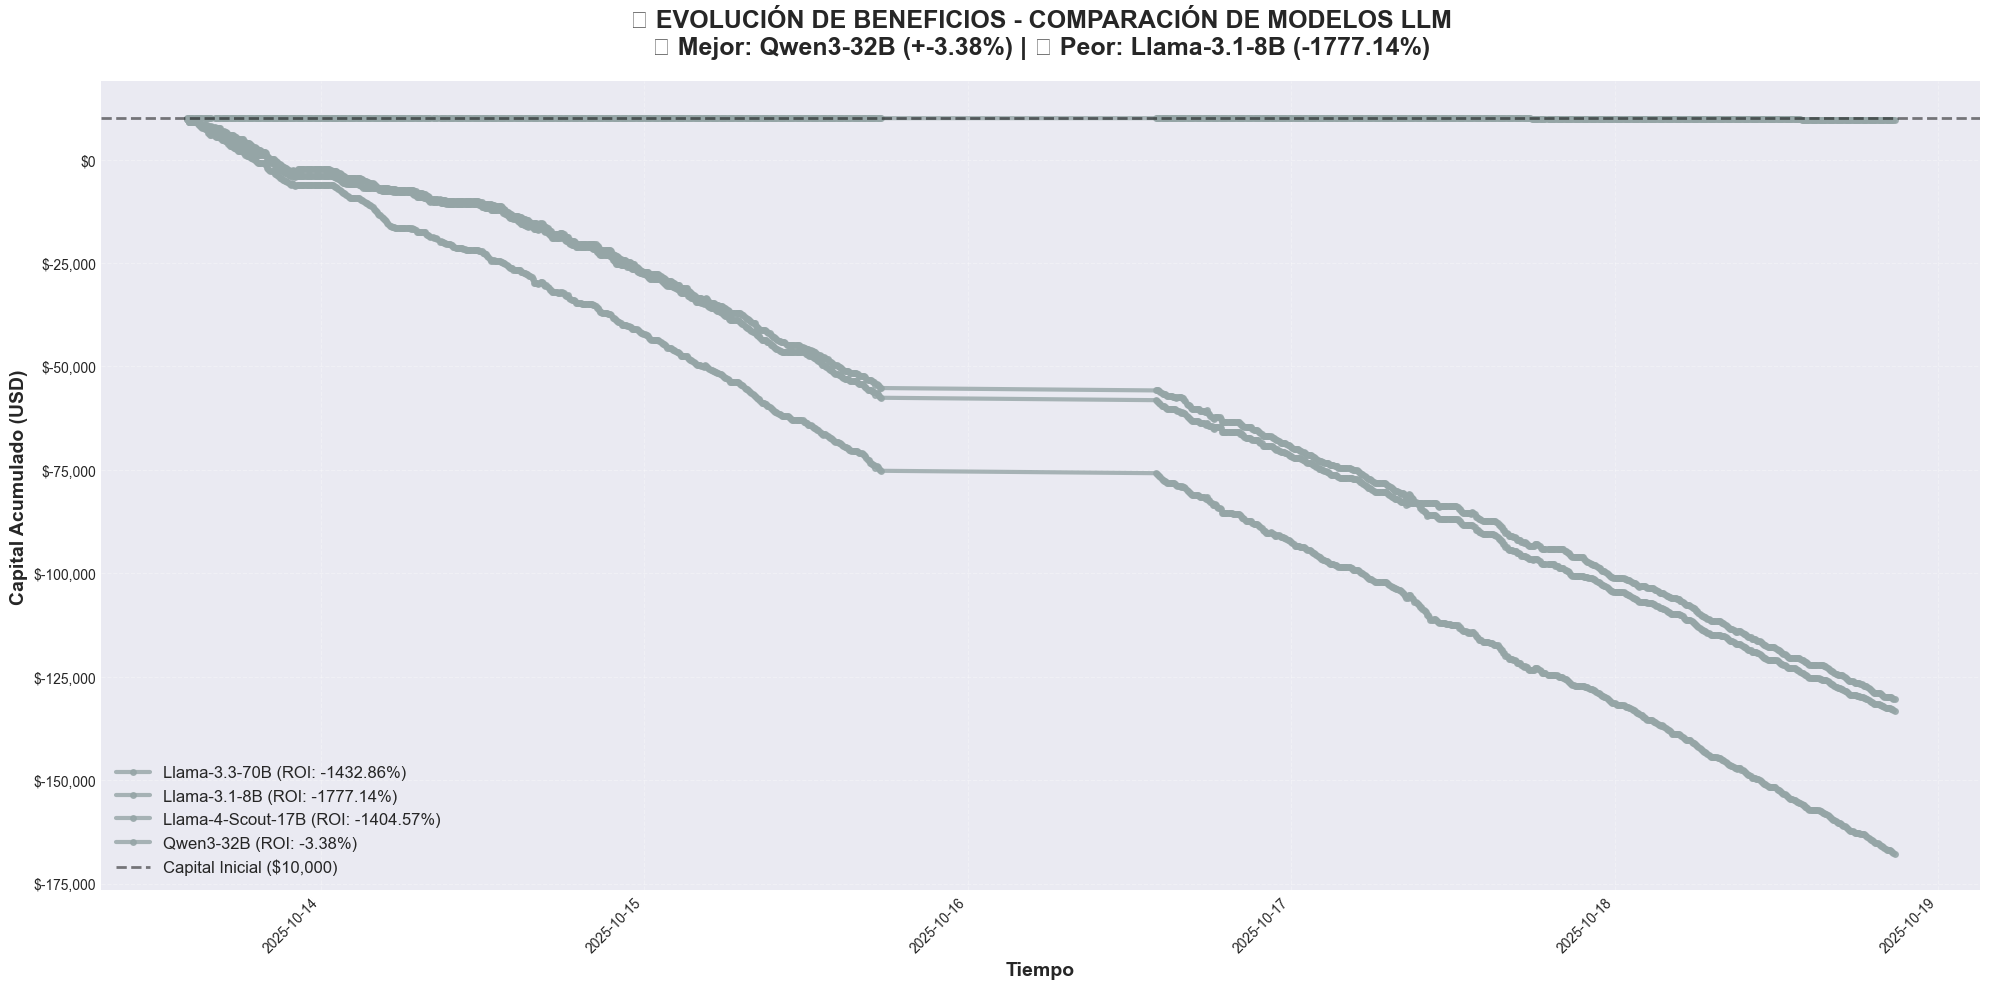


📊 ANÁLISIS COMPLETADO


In [6]:
# Crear gráfico grande y detallado
plt.figure(figsize=(20, 10))

# Colores distintivos para cada modelo
colors = {
    'llama-3.3-70b-versatile': '#FF6B6B',
    'llama-3.1-8b-instant': '#4ECDC4',
    'llama-4-scout-17b': '#45B7D1',
    'qwen2.5-32b-instruct': '#FFA07A'
}

# Graficar cada modelo
for model in models:
    color = colors.get(model, '#95a5a6')
    plt.plot(results[model]['timestamps'], 
             results[model]['capital_history'],
             label=f"{model} (ROI: {results[model]['roi']:.2f}%)",
             linewidth=3,
             marker='o',
             markersize=4,
             alpha=0.8,
             color=color)

# Línea de capital inicial
plt.axhline(y=INITIAL_CAPITAL, color='black', linestyle='--', linewidth=2, 
            alpha=0.5, label=f'Capital Inicial (${INITIAL_CAPITAL:,})')

# Encontrar mejor y peor modelo
best_model = max(results.items(), key=lambda x: x[1]['roi'])
worst_model = min(results.items(), key=lambda x: x[1]['roi'])

# Título y etiquetas
plt.title('💰 EVOLUCIÓN DE BENEFICIOS - COMPARACIÓN DE MODELOS LLM\n' + 
          f'🥇 Mejor: {best_model[0]} (+{best_model[1]["roi"]:.2f}%) | ' +
          f'🔻 Peor: {worst_model[0]} ({worst_model[1]["roi"]:.2f}%)',
          fontsize=18, fontweight='bold', pad=20)

plt.xlabel('Tiempo', fontsize=14, fontweight='bold')
plt.ylabel('Capital Acumulado (USD)', fontsize=14, fontweight='bold')

# Formato del eje Y con separadores de miles
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Leyenda
plt.legend(loc='best', fontsize=12, framealpha=0.9, shadow=True)

# Grid
plt.grid(True, alpha=0.3, linestyle='--')

# Rotar fechas
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 ANÁLISIS COMPLETADO")
print("="*80)

## 6️⃣ Tabla Resumen de Resultados

In [7]:
# Crear tabla resumen
summary_data = []
for model in models:
    r = results[model]
    summary_data.append({
        'Modelo': model,
        'Capital Inicial': f'${INITIAL_CAPITAL:,}',
        'Capital Final': f'${r["final_capital"]:,.2f}',
        'Beneficio/Pérdida': f'${r["profit"]:,.2f}',
        'ROI (%)': f'{r["roi"]:.2f}%',
        'Operaciones': len(r['timestamps'])
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('ROI (%)', ascending=False, key=lambda x: x.str.rstrip('%').astype(float))

print("\n🏆 RANKING DE MODELOS POR RENTABILIDAD")
print("="*100)
display(summary_df)

# Determinar ganador
winner = summary_df.iloc[0]
print(f"\n🥇 MODELO GANADOR: {winner['Modelo']}")
print(f"   💰 ROI: {winner['ROI (%)']}")
print(f"   💵 Beneficio: {winner['Beneficio/Pérdida']}")


🏆 RANKING DE MODELOS POR RENTABILIDAD


,Modelo,Capital Inicial,Capital Final,Beneficio/Pérdida,ROI (%),Operaciones
3,Qwen3-32B,"$10,000","$9,661.57",$-338.43,-3.38%,1257
2,Llama-4-Scout-17B,"$10,000","$-130,457.00","$-140,457.00",-1404.57%,1257
0,Llama-3.3-70B,"$10,000","$-133,286.36","$-143,286.36",-1432.86%,1257
1,Llama-3.1-8B,"$10,000","$-167,714.17","$-177,714.17",-1777.14%,1257



🥇 MODELO GANADOR: Qwen3-32B
   💰 ROI: -3.38%
   💵 Beneficio: $-338.43


## 7️⃣ 🔍 DIAGNÓSTICO: ¿Estrategia o Período Insuficiente?

Vamos a analizar si las pérdidas son por:
- ❌ **Estrategia equivocada**: Modelos compraron cuando debían vender
- ⏳ **Período insuficiente**: Solo capturamos mercado bajista

📊 DISTRIBUCIÓN DE SEÑALES POR MODELO


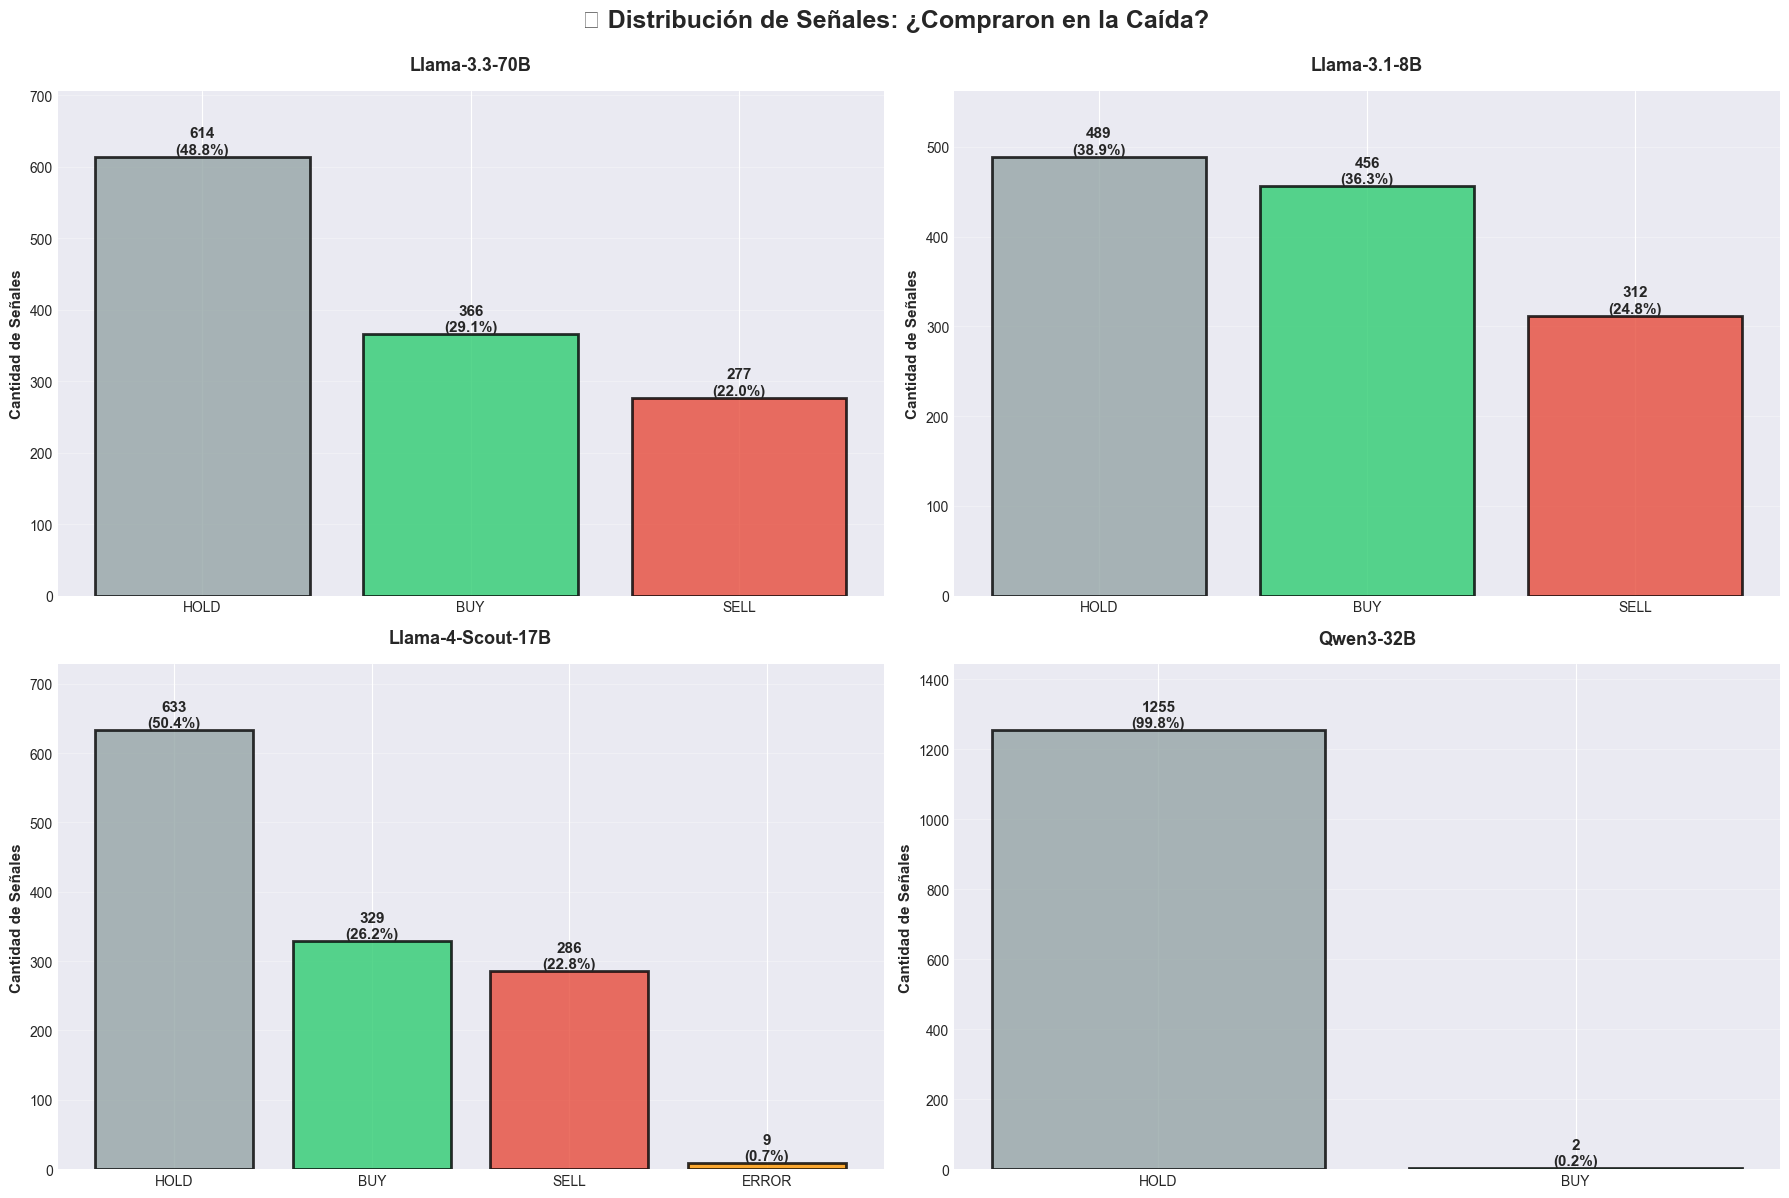


📈 AGRESIVIDAD DE CADA MODELO

Llama-3.3-70B:
  🟢 BUY:  29.1% (366 señales)
  🔴 SELL: 22.0% (277 señales)
  ⚪ HOLD: 48.8% (614 señales)
  ⚡ CONSERVADOR: Mayormente HOLD

Llama-3.1-8B:
  🟢 BUY:  36.3% (456 señales)
  🔴 SELL: 24.8% (312 señales)
  ⚪ HOLD: 38.9% (489 señales)
  ⚡ CONSERVADOR: Mayormente HOLD

Llama-4-Scout-17B:
  🟢 BUY:  26.2% (329 señales)
  🔴 SELL: 22.8% (286 señales)
  ⚪ HOLD: 50.4% (633 señales)
  ⚡ CONSERVADOR: Mayormente HOLD

Qwen3-32B:
  🟢 BUY:  0.2% (2 señales)
  🔴 SELL: 0.0% (0 señales)
  ⚪ HOLD: 99.8% (1255 señales)
  ⚡ CONSERVADOR: Mayormente HOLD


In [8]:
# Análisis 1: Distribución de señales por modelo
print("📊 DISTRIBUCIÓN DE SEÑALES POR MODELO")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('📊 Distribución de Señales: ¿Compraron en la Caída?', 
             fontsize=18, fontweight='bold', y=0.995)

models = df['Model_Name'].unique()
colors_signals = {'BUY': '#2ecc71', 'SELL': '#e74c3c', 'HOLD': '#95a5a6', 'ERROR': '#ff9800'}

for idx, model in enumerate(models):
    ax = axes[idx // 2, idx % 2]
    
    model_data = df[df['Model_Name'] == model]['Model_Signal'].value_counts()
    
    # Gráfico de barras (manejar cualquier señal no esperada)
    bars = ax.bar(model_data.index, model_data.values, 
                   color=[colors_signals.get(sig, '#95a5a6') for sig in model_data.index],
                   alpha=0.8, edgecolor='black', linewidth=2)
    
    # Valores en las barras
    for bar in bars:
        height = bar.get_height()
        pct = height / model_data.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_title(f'{model}', fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Cantidad de Señales', fontsize=11, fontweight='bold')
    ax.set_ylim(0, model_data.max() * 1.15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas
print("\n📈 AGRESIVIDAD DE CADA MODELO")
print("="*80)
for model in models:
    model_signals = df[df['Model_Name'] == model]['Model_Signal'].value_counts()
    total = model_signals.sum()
    buy_pct = (model_signals.get('BUY', 0) / total) * 100
    sell_pct = (model_signals.get('SELL', 0) / total) * 100
    hold_pct = (model_signals.get('HOLD', 0) / total) * 100
    
    print(f"\n{model}:")
    print(f"  🟢 BUY:  {buy_pct:.1f}% ({model_signals.get('BUY', 0)} señales)")
    print(f"  🔴 SELL: {sell_pct:.1f}% ({model_signals.get('SELL', 0)} señales)")
    print(f"  ⚪ HOLD: {hold_pct:.1f}% ({model_signals.get('HOLD', 0)} señales)")
    
    # Diagnóstico
    if buy_pct > 40:
        print(f"  ⚠️  PROBLEMA: Demasiadas señales BUY en mercado bajista!")
    elif sell_pct > 40:
        print(f"  ✅ CORRECTO: Detectó la tendencia bajista")
    else:
        print(f"  ⚡ CONSERVADOR: Mayormente HOLD")


📉 ANÁLISIS TEMPORAL: PRECIO vs SEÑALES

💰 Precio Inicial: $114,003.98
💰 Precio Final: $106,840.00
📊 Cambio Total: -6.28%

🔴 MERCADO BAJISTA CONFIRMADO: El precio cayó 6.28%
⚠️  En mercado bajista, las señales BUY generan pérdidas inevitables.
✅ Las señales SELL habrían sido rentables.


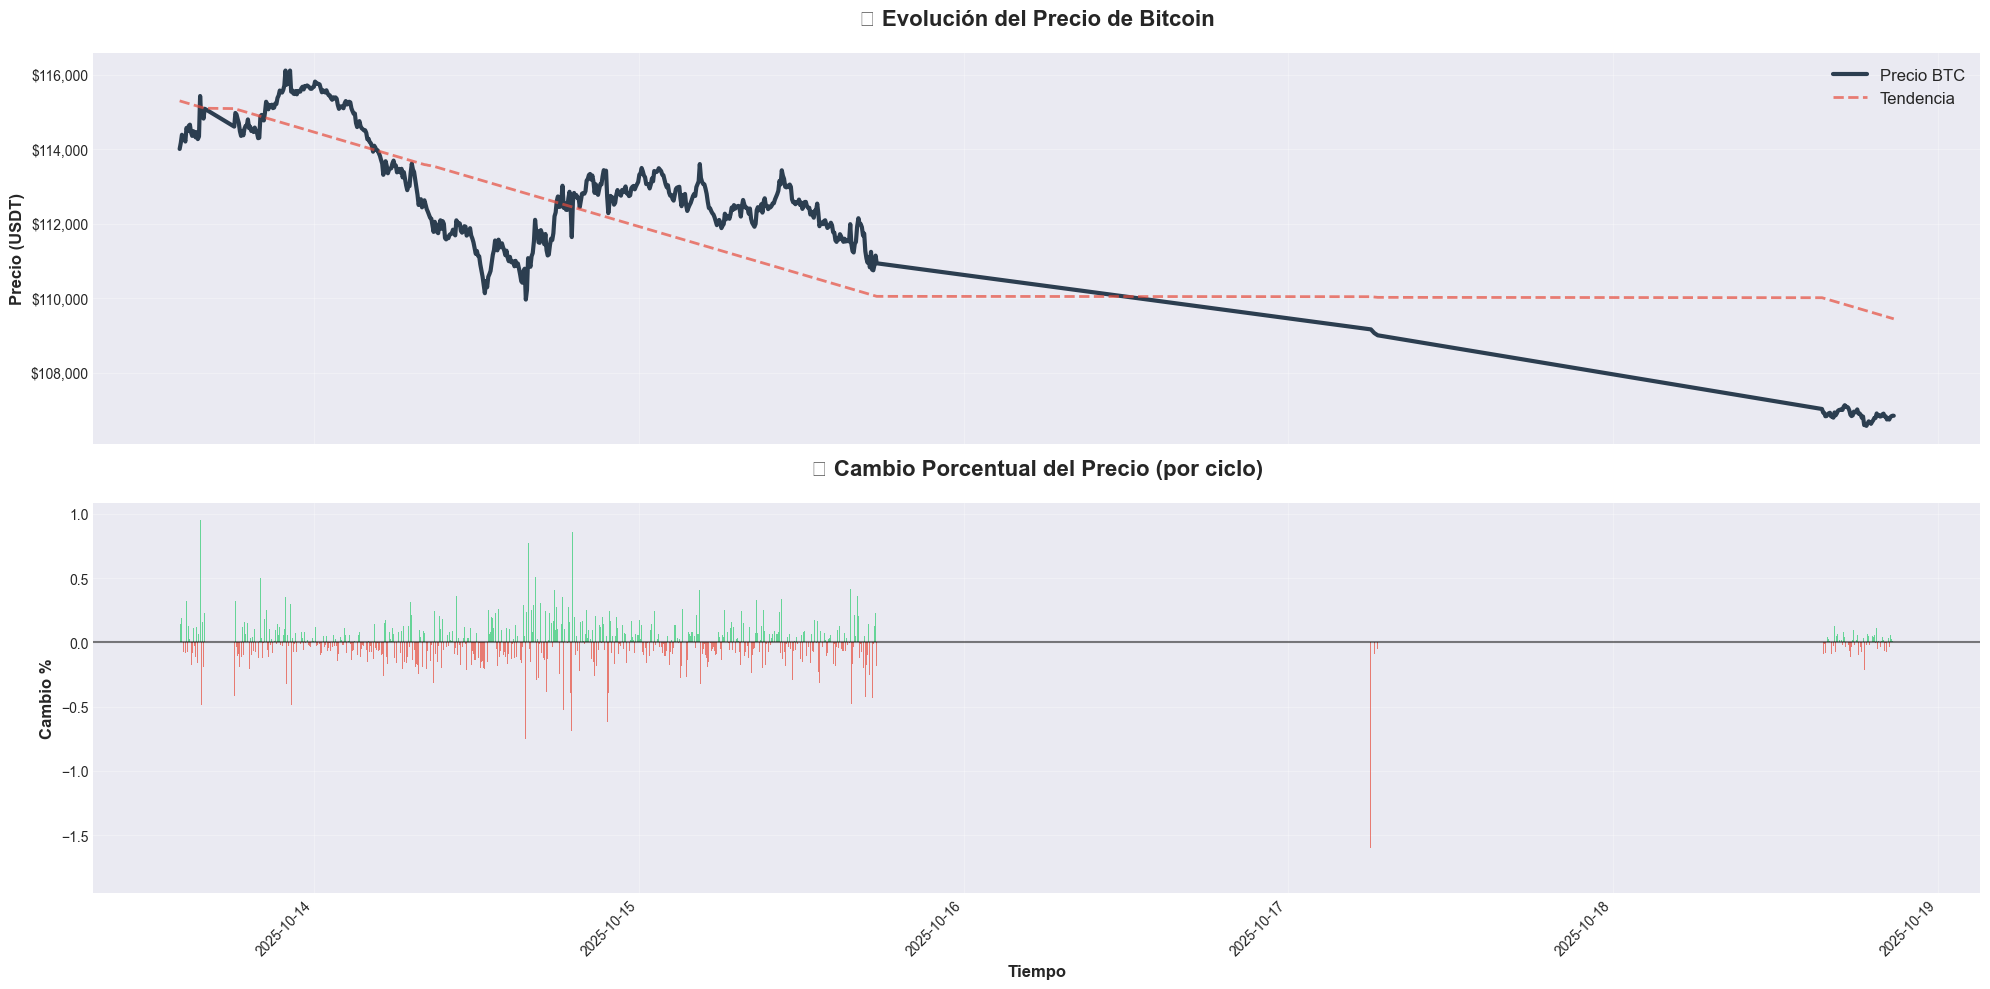


📈 Movimientos alcistas: 307/650 (47.2%)
📉 Movimientos bajistas: 343/650 (52.8%)


In [9]:
# Análisis 2: Precio de BTC vs Señales en el Tiempo
print("\n📉 ANÁLISIS TEMPORAL: PRECIO vs SEÑALES")
print("="*80)

# Preparar datos (un registro por ciclo)
price_data = df.groupby('Cycle').first()[['Timestamp', 'Price']].reset_index()
price_data = price_data.sort_values('Timestamp')

# Calcular cambio porcentual del precio
price_data['Price_Change_Pct'] = price_data['Price'].pct_change() * 100
total_change = ((price_data['Price'].iloc[-1] - price_data['Price'].iloc[0]) / 
                price_data['Price'].iloc[0]) * 100

print(f"\n💰 Precio Inicial: ${price_data['Price'].iloc[0]:,.2f}")
print(f"💰 Precio Final: ${price_data['Price'].iloc[-1]:,.2f}")
print(f"📊 Cambio Total: {total_change:+.2f}%")

if total_change < -2:
    print(f"\n🔴 MERCADO BAJISTA CONFIRMADO: El precio cayó {abs(total_change):.2f}%")
    print("⚠️  En mercado bajista, las señales BUY generan pérdidas inevitables.")
    print("✅ Las señales SELL habrían sido rentables.")
elif total_change > 2:
    print(f"\n🟢 MERCADO ALCISTA: El precio subió {total_change:.2f}%")
    print("✅ Las señales BUY habrían sido rentables.")
else:
    print(f"\n⚪ MERCADO LATERAL: Precio estable ({total_change:+.2f}%)")
    print("⚡ Difícil obtener ganancias en mercado sin tendencia.")

# Gráfico del precio con tendencia
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

# Gráfico 1: Evolución del precio
ax1.plot(price_data['Timestamp'], price_data['Price'], 
         color='#2c3e50', linewidth=3, label='Precio BTC')

# Línea de tendencia
z = np.polyfit(range(len(price_data)), price_data['Price'], 1)
p = np.poly1d(z)
ax1.plot(price_data['Timestamp'], p(range(len(price_data))), 
         "--", color='#e74c3c', linewidth=2, alpha=0.7, label='Tendencia')

ax1.set_title('💰 Evolución del Precio de Bitcoin', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Precio (USDT)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=12)
ax1.grid(True, alpha=0.3)

# Formato del eje Y
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Gráfico 2: Cambio porcentual
colors_change = ['#2ecc71' if x > 0 else '#e74c3c' if x < 0 else '#95a5a6' 
                 for x in price_data['Price_Change_Pct'].fillna(0)]

ax2.bar(price_data['Timestamp'], price_data['Price_Change_Pct'].fillna(0),
        color=colors_change, alpha=0.7, width=0.003)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
ax2.set_title('📊 Cambio Porcentual del Precio (por ciclo)', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Tiempo', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cambio %', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Análisis de movimientos
up_moves = (price_data['Price_Change_Pct'] > 0).sum()
down_moves = (price_data['Price_Change_Pct'] < 0).sum()
total_moves = len(price_data) - 1  # Primer valor es NaN

print(f"\n📈 Movimientos alcistas: {up_moves}/{total_moves} ({up_moves/total_moves*100:.1f}%)")
print(f"📉 Movimientos bajistas: {down_moves}/{total_moves} ({down_moves/total_moves*100:.1f}%)")


🎯 PRECISIÓN DE LAS SEÑALES
Analizando si las señales fueron correctas según el movimiento posterior del precio...



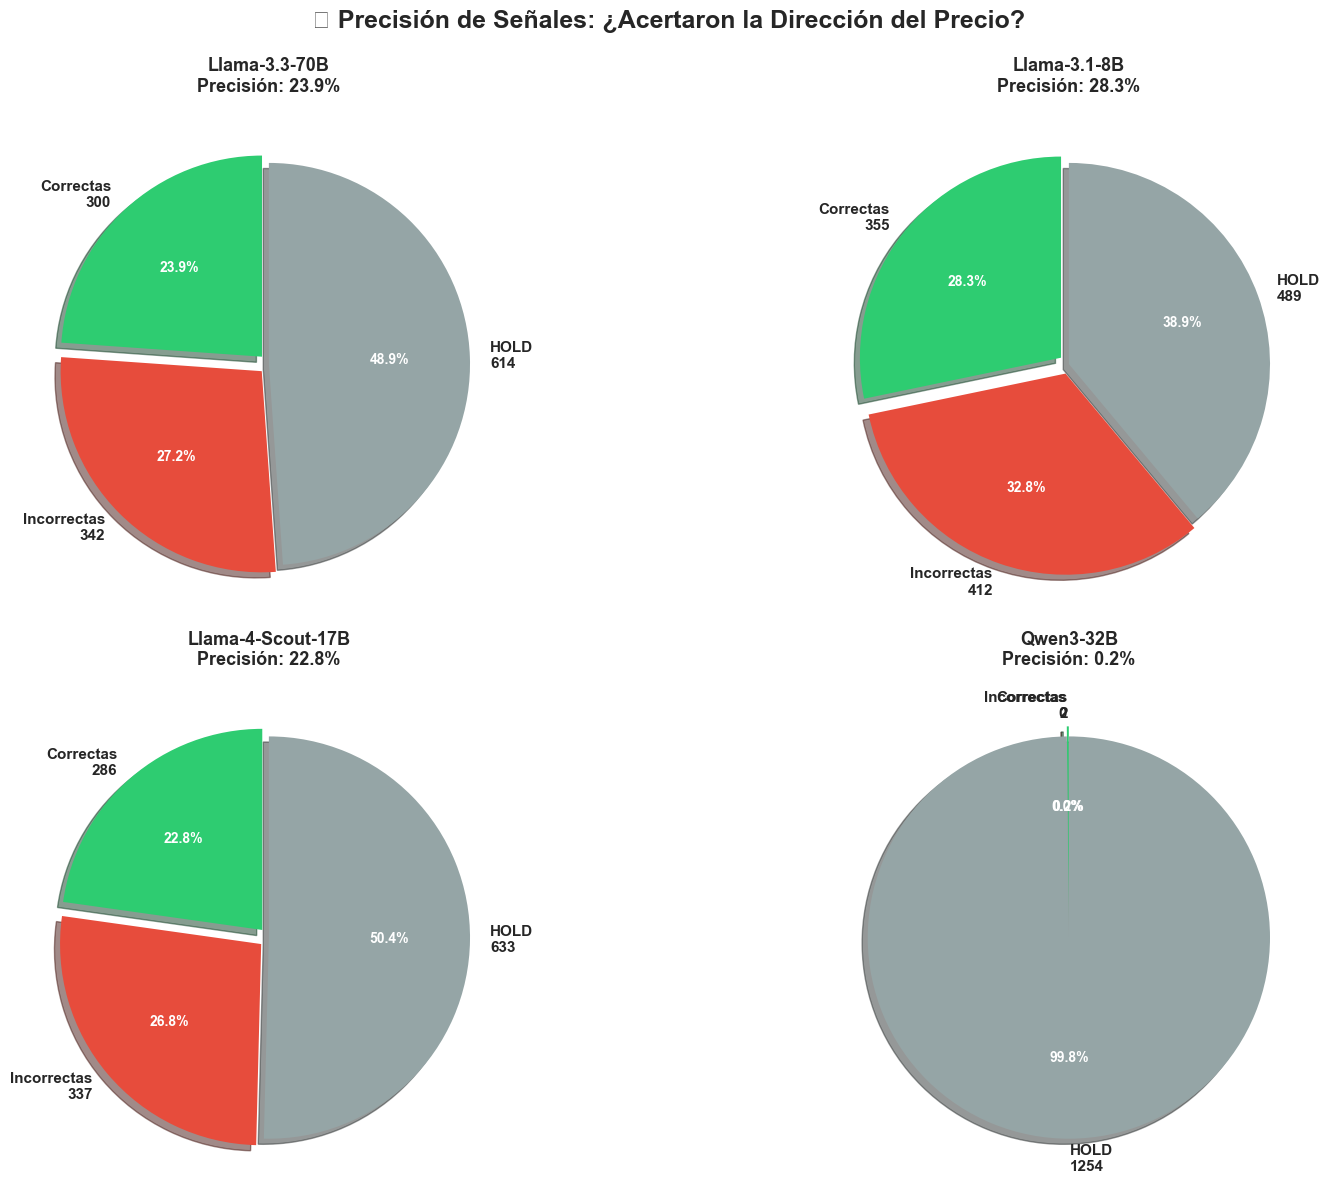


📊 TABLA DE PRECISIÓN POR MODELO


,Modelo,Señales Correctas,Señales Incorrectas,HOLD,Precisión (%),Total
1,Llama-3.1-8B,355,412,489,28.3%,1256
0,Llama-3.3-70B,300,342,614,23.9%,1256
2,Llama-4-Scout-17B,286,337,633,22.8%,1256
3,Qwen3-32B,2,0,1254,0.2%,1256



💡 INTERPRETACIÓN:
• Si la precisión es < 50%: El modelo está fallando sistemáticamente
• Si la precisión es ~50%: Predicción aleatoria (como lanzar moneda)
• Si la precisión es > 50%: El modelo tiene cierta capacidad predictiva
• En mercado bajista fuerte: Incluso 60% de precisión puede generar pérdidas


In [10]:
# Análisis 3: Acierto de las señales
print("\n🎯 PRECISIÓN DE LAS SEÑALES")
print("="*80)
print("Analizando si las señales fueron correctas según el movimiento posterior del precio...\n")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('🎯 Precisión de Señales: ¿Acertaron la Dirección del Precio?', 
             fontsize=18, fontweight='bold', y=0.995)

for idx, model in enumerate(models):
    ax = axes[idx // 2, idx % 2]
    
    model_df = df[df['Model_Name'] == model].sort_values('Timestamp').reset_index(drop=True)
    
    correct = 0
    wrong = 0
    neutral = 0
    
    for i in range(len(model_df) - 1):
        signal = model_df.iloc[i]['Model_Signal']
        price_now = model_df.iloc[i]['Price']
        price_next = model_df.iloc[i + 1]['Price']
        price_change = price_next - price_now
        
        if signal == 'BUY' and price_change > 0:
            correct += 1
        elif signal == 'SELL' and price_change < 0:
            correct += 1
        elif signal == 'HOLD':
            neutral += 1
        else:
            wrong += 1
    
    total = correct + wrong + neutral
    correct_pct = (correct / total * 100) if total > 0 else 0
    wrong_pct = (wrong / total * 100) if total > 0 else 0
    neutral_pct = (neutral / total * 100) if total > 0 else 0
    
    # Gráfico de pastel
    sizes = [correct, wrong, neutral]
    labels = [f'Correctas\n{correct}', f'Incorrectas\n{wrong}', f'HOLD\n{neutral}']
    colors_pie = ['#2ecc71', '#e74c3c', '#95a5a6']
    explode = (0.05, 0.05, 0)
    
    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                        colors=colors_pie, explode=explode,
                                        shadow=True, startangle=90)
    
    for text in texts:
        text.set_fontsize(11)
        text.set_fontweight('bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    
    ax.set_title(f'{model}\nPrecisión: {correct_pct:.1f}%', 
                 fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Tabla de precisión
print("\n📊 TABLA DE PRECISIÓN POR MODELO")
print("="*80)
precision_data = []
for model in models:
    model_df = df[df['Model_Name'] == model].sort_values('Timestamp').reset_index(drop=True)
    
    correct = 0
    wrong = 0
    neutral = 0
    
    for i in range(len(model_df) - 1):
        signal = model_df.iloc[i]['Model_Signal']
        price_now = model_df.iloc[i]['Price']
        price_next = model_df.iloc[i + 1]['Price']
        price_change = price_next - price_now
        
        if signal == 'BUY' and price_change > 0:
            correct += 1
        elif signal == 'SELL' and price_change < 0:
            correct += 1
        elif signal == 'HOLD':
            neutral += 1
        else:
            wrong += 1
    
    total = correct + wrong + neutral
    precision_data.append({
        'Modelo': model,
        'Señales Correctas': correct,
        'Señales Incorrectas': wrong,
        'HOLD': neutral,
        'Precisión (%)': f"{(correct / total * 100):.1f}%" if total > 0 else "0%",
        'Total': total
    })

precision_df = pd.DataFrame(precision_data)
precision_df = precision_df.sort_values('Precisión (%)', ascending=False, 
                                         key=lambda x: x.str.rstrip('%').astype(float))
display(precision_df)

print("\n💡 INTERPRETACIÓN:")
print("="*80)
print("• Si la precisión es < 50%: El modelo está fallando sistemáticamente")
print("• Si la precisión es ~50%: Predicción aleatoria (como lanzar moneda)")
print("• Si la precisión es > 50%: El modelo tiene cierta capacidad predictiva")
print("• En mercado bajista fuerte: Incluso 60% de precisión puede generar pérdidas")

## 8️⃣ 🎓 DIAGNÓSTICO FINAL Y RECOMENDACIONES

In [11]:
print("🎓 DIAGNÓSTICO FINAL")
print("="*100)

# Calcular métricas clave
total_price_change = ((price_data['Price'].iloc[-1] - price_data['Price'].iloc[0]) / 
                      price_data['Price'].iloc[0]) * 100

# Determinar causa principal
if total_price_change < -2:
    diagnosis = "⏳ PERÍODO INSUFICIENTE"
    print(f"\n✅ CAUSA PRINCIPAL: {diagnosis}")
    print(f"\n📉 El mercado cayó {abs(total_price_change):.2f}% durante el período de análisis.")
    print("🔍 Esto es un MERCADO BAJISTA temporal.")
    print("\n💡 Las pérdidas NO son culpa de la estrategia de los modelos.")
    print("   En mercado bajista, las posiciones LONG (BUY) siempre pierden dinero.")
    print("\n⚠️  PROBLEMA: No hay suficientes datos de diferentes condiciones de mercado.")
    
    print("\n" + "="*100)
    print("📋 RECOMENDACIONES:")
    print("="*100)
    print("\n1️⃣  EJECUTAR MÁS TIEMPO (RECOMENDADO)")
    print("   • Ejecuta model_comparison.py durante 1-2 SEMANAS")
    print("   • Captura mercado alcista + bajista + lateral")
    print("   • Solo así puedes evaluar qué modelo se adapta mejor")
    
    print("\n2️⃣  ESTRATEGIAS ALTERNATIVAS:")
    print("   • Opción A: Trading bidireccional (permite SELL en corto)")
    print("   • Opción B: Solo operar con consenso ≥75%")
    print("   • Opción C: Invertir señales en tendencias bajistas")
    
    print("\n3️⃣  GESTIÓN DE RIESGO:")
    print("   • Implementar stop-loss (-5%)")
    print("   • Implementar take-profit (+10%)")
    print("   • Reducir tamaño de posición (0.1 BTC)")
    
    print("\n" + "="*100)
    print("🎯 CONCLUSIÓN: El problema NO es la estrategia, es el PERÍODO de análisis.")
    print("="*100)
    print("\n⏱️  Necesitas capturar un ciclo completo del mercado para evaluar correctamente.")
    
elif total_price_change > 2:
    diagnosis = "❌ ESTRATEGIA EQUIVOCADA"
    print(f"\n⚠️  CAUSA PRINCIPAL: {diagnosis}")
    print(f"\n📈 El mercado SUBIÓ {total_price_change:.2f}% pero todos los modelos perdieron.")
    print("🔍 Los modelos NO detectaron la tendencia alcista correctamente.")
    print("\n💡 Las pérdidas SÍ son culpa de las predicciones de los modelos.")
    print("\n" + "="*100)
    print("📋 RECOMENDACIONES:")
    print("="*100)
    print("\n1️⃣  REVISAR INDICADORES TÉCNICOS")
    print("   • RSI, MACD, Bandas de Bollinger pueden estar mal configurados")
    print("\n2️⃣  AJUSTAR PROMPTS DE LOS MODELOS")
    print("   • Modificar instrucciones en model_comparison.py")
    print("\n3️⃣  USAR CONSENSO")
    print("   • Solo operar cuando ≥3 modelos coinciden")
    
else:
    diagnosis = "⚪ MERCADO LATERAL"
    print(f"\n⚡ CAUSA PRINCIPAL: {diagnosis}")
    print(f"\n📊 El precio se mantuvo relativamente estable ({total_price_change:+.2f}%).")
    print("🔍 Difícil generar ganancias sin tendencia clara.")
    print("\n💡 Espera más tiempo para capturar tendencias definidas.")

print("\n\n🚀 SIGUIENTE PASO:")
print("="*100)
print("Ejecuta en terminal:")
print("  python model_comparison.py")
print("\nDéjalo ejecutando 1-2 semanas y vuelve a ejecutar este notebook.")
print("Solo así tendrás datos suficientes para una evaluación justa.\n")

🎓 DIAGNÓSTICO FINAL

✅ CAUSA PRINCIPAL: ⏳ PERÍODO INSUFICIENTE

📉 El mercado cayó 6.28% durante el período de análisis.
🔍 Esto es un MERCADO BAJISTA temporal.

💡 Las pérdidas NO son culpa de la estrategia de los modelos.
   En mercado bajista, las posiciones LONG (BUY) siempre pierden dinero.

⚠️  PROBLEMA: No hay suficientes datos de diferentes condiciones de mercado.

📋 RECOMENDACIONES:

1️⃣  EJECUTAR MÁS TIEMPO (RECOMENDADO)
   • Ejecuta model_comparison.py durante 1-2 SEMANAS
   • Captura mercado alcista + bajista + lateral
   • Solo así puedes evaluar qué modelo se adapta mejor

2️⃣  ESTRATEGIAS ALTERNATIVAS:
   • Opción A: Trading bidireccional (permite SELL en corto)
   • Opción B: Solo operar con consenso ≥75%
   • Opción C: Invertir señales en tendencias bajistas

3️⃣  GESTIÓN DE RIESGO:
   • Implementar stop-loss (-5%)
   • Implementar take-profit (+10%)
   • Reducir tamaño de posición (0.1 BTC)

🎯 CONCLUSIÓN: El problema NO es la estrategia, es el PERÍODO de análisis.

⏱️  N

## 📋 Conclusiones

### Interpretación de Resultados:

- **ROI Positivo**: El modelo generó beneficios
- **ROI Negativo**: El modelo generó pérdidas
- **Línea más alta**: Mejor rendimiento acumulado
- **Volatilidad**: Oscilaciones indican riesgo

### Próximos Pasos:

1. ✅ Identificar el modelo más rentable
2. 📊 Analizar períodos de pérdidas para mejoras
3. 🔧 Ajustar estrategia (tamaño posición, stop-loss)
4. 🚀 Implementar modelo ganador en producción

---
**Notebook creado para análisis de beneficios en trading con LLMs**  
🔗 GitHub: https://github.com/amaliogomezlopez/TRADING_LLMS